# OCEN4005 ocean particle tracking exercise


Demonstrate the ocean particle (Lagrangian) tracking model: [https://oceanparcels.org/](https://oceanparcels.org/). We will use ocean currents simulated with the [Perth ROMS model](http://boreas.mywire.org:8080/perth.html).



In [1]:
# Run this code block to setup the environment
# %pip install netcdf4 h5netcdf parcels
# %pip install parcels

In [12]:
# Import relevant python modules
import xarray as xr
from datetime import datetime, timedelta

import numpy as np
import zarr
import matplotlib.pyplot as plt

# from ipyleaflet import Map, TileLayer, basemaps, Polyline
from cartopy.io.img_tiles import GoogleTiles
from cartopy import crs as ccrs, feature as cfeature
import pandas as pd

from parcels import AdvectionRK4, FieldSet, ParticleSet, ScipyParticle

In [32]:
###################################
# Change these variables
###################################

lon_release = 115.4
lat_release = -31.9

release_year = 2026
release_month = 2
release_day = 11
release_hour = 3

# Number of days to track particles
runtime_parcels = 72 # hours

###################################
# End of variables to change
###################################

# Other parcels variables (don't change these)
dt_parcels = 1 # Hours
dtout_parcels = 1 # hours

# # Number of particles
# number_particles=5

# # Particles are release randomly in this box
# lon_range=(lon_release-0.01,lon_release+0.01)
# lat_range=(lat_release-0.01,lat_release+0.01)

lonp = np.array([115.4159032034, 115.372843321374, 115.415120296454])
latp = np.array([-32.0031507153646, -31.9825994080343, -31.9595036531297])


In [33]:
# Ivica's ROMS data lives here
# http://boreas.mywire.org:8080/thredds/catalog/perthqck/catalog.html
# url = "http://boreas.mywire.org:8080/thredds/dodsC/perthqck/perth_qck_2026.ncml"
url = "http://boreas.mywire.org:8080/thredds/dodsC/cwaqck/cwa_qck_202601.ncml"
# Merge two data sets
vel = xr.open_dataset(url)

# urls = ["http://boreas.mywire.org:8080/thredds/dodsC/perthqck/perth_qck_20260211.nc",
#        "http://boreas.mywire.org:8080/thredds/dodsC/perthqck/perth_qck_20260212.nc",
#        "http://boreas.mywire.org:8080/thredds/dodsC/perthqck/perth_qck_20260213.nc",
#        "http://boreas.mywire.org:8080/thredds/dodsC/perthqck/perth_qck_20260214.nc",
# ]
# vel = xr.open_mfdataset(urls, engine='h5netcdf')

vel

<xarray.Dataset> Size: 10GB
Dimensions:          (tracer: 2, s_rho: 25, s_w: 26, boundary: 4, eta_rho: 640,
                      xi_rho: 480, ocean_time: 1104)
Coordinates:
    lat_rho          (eta_rho, xi_rho) float64 2MB ...
    lon_rho          (eta_rho, xi_rho) float64 2MB ...
  * s_rho            (s_rho) float64 200B -0.98 -0.94 -0.9 ... -0.1 -0.06 -0.02
  * s_w              (s_w) float64 208B -1.0 -0.96 -0.92 ... -0.08 -0.04 0.0
  * ocean_time       (ocean_time) datetime64[ns] 9kB 2026-01-01 ... 2026-02-1...
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho
Data variables: (12/70)
    Akk_bak          float32 4B ...
    Akp_bak          float32 4B ...
    Akt_bak          (tracer) float32 8B ...
    Akv_bak          float32 4B ...
    Cs_r             (s_rho) float64 200B ...
    Cs_w             (s_w) float64 208B ...
    ...               ...
    temp_sur         (ocean_time, eta_rho, xi_rho) float32 1GB ...
    u_sur_eastward   (ocean_time, eta_rho, xi_rho) float32 1GB ...
    ubar_eastward    (ocean_time, eta_rho, xi_rho) float32 1GB ...
    v_sur_northward  (ocean_time, eta_rho, xi_rho) float32 1GB ...
    vbar_northward   (ocean_time, eta_rho, xi_rho) float32 1GB ...
    zeta             (ocean_time, eta_rho, xi_rho) float32 1GB ...
Attributes: (12/36)
    file:                       ./outputs/cwa_qck.nc
    format:                     netCDF-3 64bit offset file
    Conventions:                CF-1.4, SGRID-0.3
    type:                       ROMS/TOMS quicksave file
    title:                      Central WA ROMS ~2km
    var_info:                   varinfo.dat
    ...                         ...
    tiling:                     004x008
    history:                    Mon Feb  9 06:59:23 2026: ncks -x -v grid /gr...
    ana_file:                   ROMS/Functionals/ana_btflux.h
    CPP_options:                CWA_ROMS_NEW, ADD_FSOBC, ADD_M2OBC, ANA_BSFLU...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...
    history_of_appended_files:  Mon Feb  9 06:59:22 2026: Appended file /grou...

In [34]:
# Subset the time to the particle time range
tstr = f"{release_year}-{release_month:02d}-{release_day:02d} {release_hour:02d}:00:00"

myvel = vel.sel(ocean_time=slice(np.datetime64(tstr),None, None))

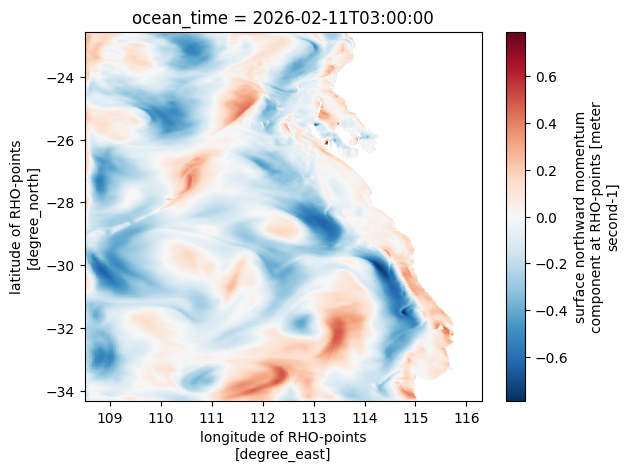

In [35]:
myvel['v_sur_northward'].isel(ocean_time=0).plot(x='lon_rho', y='lat_rho')


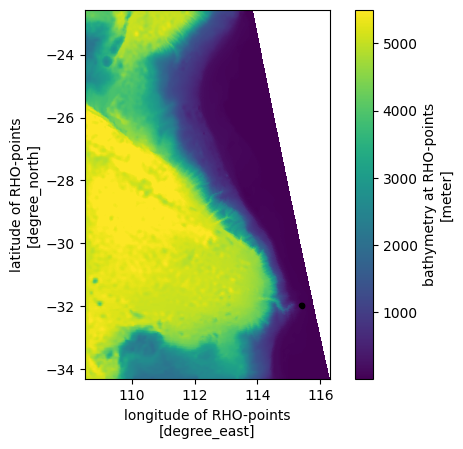

In [36]:
# Creat the Parcels field object
fieldset = FieldSet.from_xarray_dataset(
    myvel,
    variables={"U": "u_sur_eastward", "V": "v_sur_northward"},
    dimensions={"lat": "lat_rho", "lon": "lon_rho", "time":"ocean_time"},
    interp_method='nearest',
)

# Create the Parcels particle object
def create_random_pset(
    fieldset=None, lon_range=(100,115), lat_range=(-30, -15), number_particles=20
):
    return ParticleSet.from_list(
        fieldset=fieldset,
        pclass=ScipyParticle,
        lon=np.random.uniform(*lon_range, size=(number_particles,)),
        lat=np.random.uniform(*lat_range, size=(number_particles,)),
        time=np.zeros(shape=(number_particles,)),
    )


#pset = create_random_pset(fieldset,
#                          lon_range=lon_range,
#                          lat_range=lat_range,
#                          number_particles=number_particles)
number_particles = lonp.shape[0]
pset= ParticleSet.from_list(
        fieldset=fieldset,
        pclass=ScipyParticle,
        lon=lonp,
        lat=latp,
        time=np.zeros(shape=(number_particles,)),
)

# Plot the particle locations
myvel['h'].plot(x='lon_rho', y='lat_rho')
plt.plot(pset.lon, pset.lat, "k.")
plt.gca().set_aspect('equal')

In [37]:
# create output store and output file
output_memorystore = zarr.storage.MemoryStore()
outputfile = pset.ParticleFile(name=output_memorystore, outputdt=timedelta(hours=dtout_parcels))

# run the experiment
pset.execute(
    AdvectionRK4,
    runtime=timedelta(hours=runtime_parcels),
    dt=timedelta(hours=dt_parcels),
    output_file=outputfile,
)

# load output
ds_out = xr.open_zarr(output_memorystore)
display(ds_out)

INFO: Output files are stored in <zarr.storage.MemoryStore object at 0x7ff4b801ef00>.
100%|██████████| 259200.0/259200.0 [00:05<00:00, 51679.35it/s]


<xarray.Dataset> Size: 5kB
Dimensions:     (trajectory: 3, obs: 72)
Coordinates:
  * obs         (obs) int32 288B 0 1 2 3 4 5 6 7 8 ... 64 65 66 67 68 69 70 71
  * trajectory  (trajectory) int64 24B 3 4 5
Data variables:
    lat         (trajectory, obs) float32 864B dask.array<chunksize=(3, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 864B dask.array<chunksize=(3, 1), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 2kB dask.array<chunksize=(3, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 864B dask.array<chunksize=(3, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        ScipyParticleAdvectionRK4
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [38]:
# have a quick look at the trajectories
# ds_out.to_dataframe().plot.scatter(x="lon", y="lat", s=2, alpha=1);

In [44]:
# PLot with some drifter data

start_date = '2026-02-11'
start_time = '03:40'

end_date = '2026-02-12'
end_time = '23:00'

mykey = '2839734D-2551-4287-805F-CBF76E9194C4' # prob should hide this in a separate file

apistr = (f"https://api.pacificgyre.com/api2/getData.aspx?apiKey={mykey}&commIDs="
        f"&startDate={start_date}%20{start_time}&endDate={end_date}%20{end_time}"
        f"&fileFormat=csv&fieldList=&orgId=236&coordinateFormat=d")

df = pd.read_csv(apistr)


In [45]:
df['DeviceDateTime'][0]

'2026-02-12 22:57:59'

Text(0.5, 1.0, 'Last drifter time: 2026-02-12 22:57:59Z')

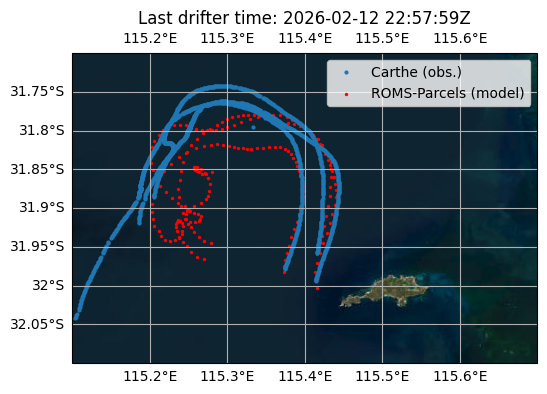

In [46]:
from cartopy.io.img_tiles import GoogleTiles

# Esri WMS/WMTS URL
class EsriImagery(GoogleTiles):
    def _image_url(self, tile):
        x,y,z = tile
        url = (f'https://server.arcgisonline.com/arcgis/rest/services/'
               f'World_Imagery/MapServer/tile/{z}/{y}/{x}')
        return url

tiler = EsriImagery()

crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(6,12))

ax = plt.subplot(111, projection=crs)
ax.plot(df['Longitude'], df['Latitude'],'o', ms=2)

# ax.coastlines(resolution='10m',color='gray', facecolor='gray')
# ax.set_facecolor(cfeature.COLORS['water'])
# ax.add_feature(cfeature.LAND)
gl=ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)
gl.right_labels = False

area = (115.1, -32.1, 115.7, -31.7) 

x1,y1, x2, y2 = area
    
ax.set_extent([
    x1,x2,y1,y2
], )

ds_out.to_dataframe().plot.scatter(ax=ax, x="lon", y="lat", c='r', s=2, alpha=1);

ax.legend(('Carthe (obs.)','ROMS-Parcels (model)'))
ax.add_image(tiler,10)

ax.set_title('Last drifter time: '+ df['DeviceDateTime'][0]+'Z')
# now = np.datetime64(df['DeviceDateTime'][0])
# ds_out.sel(time=now, method='nearest').to_dataframe().plot.scatter(ax=ax, x="lon", y="lat", marker='*', c='r', s=4, alpha=1);


In [10]:
# Create a list of output points
X, Y = ds_out['lon'].values, ds_out['lat'].values
locations = [[[Y[ii,jj],X[ii,jj]] for jj in range(runtime_parcels)] for ii in range(number_particles)]

In [11]:
# Plot the a
# See: https://ipyleaflet.readthedocs.io/en/latest/map_and_basemaps/basemaps.html
center = [-32, 115]
zoom = 9
# basemap = basemaps.Esri.NatGeoWorldMap
basemap = basemaps.Esri.WorldImagery
# basemap = basemaps.NASAGIBS.ViirsTrueColorCR
m = Map(center=center, zoom=zoom, interpolation='nearest', basemap=basemap)

line = Polyline(
    locations=locations,
    color="blue" ,
    smooth_factor=0.1,
    fill=False
)

m.add(line)

m

Map(center=[-32, 115], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_t…

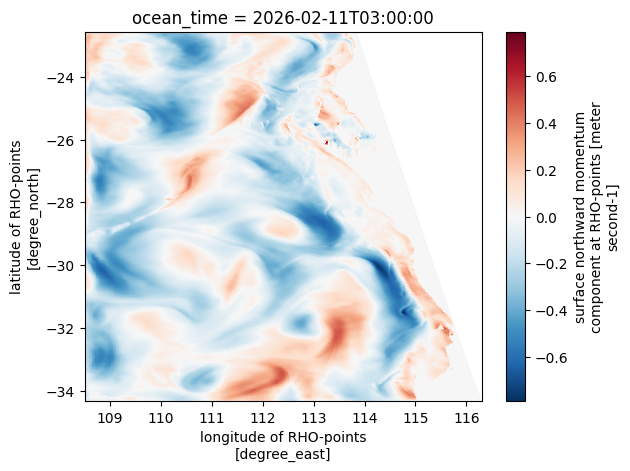

In [12]:
2
myvel['v_sur_northward'].isel(ocean_time=0).plot(x='lon_rho', y='lat_rho')
# myvel['u_sur_eastward'].isel(ocean_time=0).plot(x='lon_rho', y='lat_rho')

In [24]:
0.5*86400

43200.0